Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0019
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.3725e-04
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.3621e-04
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0023e-04
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.6117e-05
Epoch 6/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.5338e-05
Epoch 7/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.5151e-05
Epoch 8/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.7944e-05
Epoch 9/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.9855e-05
Epoch 10/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.1717e-05
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


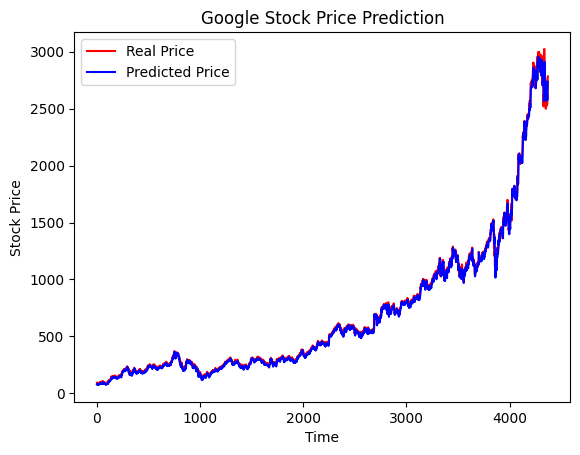

In [ ]:
# Simple RNN with Graph Plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Load dataset
data = pd.read_csv("GOOGL.csv")

# Select Open price column
prices = data.iloc[:, 1:2].values

# Scale data
sc = MinMaxScaler()
prices_scaled = sc.fit_transform(prices)

# Create training data
X = []
y = []

for i in range(60, len(prices_scaled)):
    X.append(prices_scaled[i-60:i, 0])
    y.append(prices_scaled[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for RNN
X = X.reshape(X.shape[0], X.shape[1], 1)

# Build RNN model
model = Sequential()
model.add(SimpleRNN(50, input_shape=(60,1)))
model.add(Dense(1))

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X, y, epochs=10, batch_size=32)

# Predict prices
predicted = model.predict(X)

# Convert predicted values back
predicted = sc.inverse_transform(predicted)

# Plot graph
plt.plot(prices[60:], color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()

plt.show()